# 04_06_04 — GPU SB с учетом транзакционных издержек на фиксированном кэше

Тетрадка объединяет две части:

1. GPU-wrapper для Simulated Bifurcation из `04_06_03_gpu_sb_cached_market_data.ipynb`;
2. построение fee-adjusted рыночного графа из `add_transactions.ipynb`.

Главный принцип: **сырые JSON-данные не перезаписываются**.  
`book_tickers.json` и `klines_<SYMBOL>_1h_240.json` только читаются из `DATA_DIR`.

Все результаты сохраняются в отдельную папку:

```text
results_gpu_fee/<RUN_TAG>/
```

Веса рёбер:

$$
w^{gross}_{ij}=s_{ij}(\operatorname{ask}_j-\operatorname{bid}_i),
$$

$$
w^{fee}_{ij}
=
s_{ij}(\operatorname{ask}_j-\operatorname{bid}_i)
+
f(\operatorname{bid}_i+\operatorname{ask}_j).
$$

Комиссия **не умножается** на similarity.

## 0. Imports, project path и проверка GPU

In [ ]:
from __future__ import annotations

import os
import sys
import time
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from typing import Optional, Dict, Tuple, List

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

sys.path.insert(0, Path.cwd())

print("Project modules path:", Path.cwd())

from dtw_similarity import (
    build_daily_sequences_from_hourly_klines,
    compute_similarity_matrix,
)
from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from pair_search import (
    CycleSolution,
    TabuList,
    verify_single_dummy_cycle,
    extract_pair_and_weight,
)

# Optional: reload modules in notebook sessions if you edited .py files.
import importlib
import qubo_cycle, ising_mapping, pair_search
importlib.reload(qubo_cycle)
importlib.reload(ising_mapping)
importlib.reload(pair_search)

from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from pair_search import (
    CycleSolution,
    TabuList,
    verify_single_dummy_cycle,
    extract_pair_and_weight,
)

# GPU check
try:
    import cupy as cp
    import cupyx.scipy.sparse as cpsp

    GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    if GPU_AVAILABLE:
        props = cp.cuda.runtime.getDeviceProperties(0)
        name = props["name"].decode() if isinstance(props["name"], bytes) else props["name"]
        print("GPU:", name)
        print("CuPy:", cp.__version__)
        print("CUDA runtime:", cp.cuda.runtime.runtimeGetVersion())
    else:
        print("No CUDA GPU detected by CuPy.")
except Exception as e:
    GPU_AVAILABLE = False
    print("CuPy/GPU is not available:", repr(e))

Project modules path: c:\sb_gpu
GPU: NVIDIA GeForce GTX 1650 SUPER
CuPy: 14.1.1
CUDA runtime: 12090


## 1. Параметры эксперимента

In [ ]:
# Input/output

# Папка с зафиксированными raw JSON:
#   book_tickers.json
#   klines_<SYMBOL>_1h_240.json
DATA_DIR = Path("binance_data_cached_20260609")

# Результаты пишутся в отдельную timestamp-папку.
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("results_gpu_fee") / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR :", OUT_DIR.resolve())

# Market / transaction cost parameters

# 0.001 = 0.1% taker fee на каждую сторону сделки.
TAKER_FEE = 0.001

# При threshold=0 принимаются только отрицательные fee-adjusted пути.
THRESHOLD = 0.0

# Similarity по последним полным дням перед snapshot/latest day.
DAYS_BACK = 5
EXCLUDE_LAST_DAY = True

# SB / QUBO parameters

MAX_PAIRS = 10
SB_VARIANT = "BSB"
N_RUNS_PER_PAIR = 100
N_ITER = 900
DT = 0.65
SEED = 42

# QUBO scaling:
# H_QUBO = MC * H_cost + MP * H_penalty
# Важно сохранять и MC, и MP для воспроизводимости.
MC = 1.0
MP = 0.1

# GPU numeric settings.
DTYPE_STR = "float32"
USE_SPARSE = False

HARD_TABU = True

print("TAKER_FEE:", TAKER_FEE)
print("MC, MP, MP/MC:", MC, MP, MP / MC)

DATA_DIR: C:\sb_gpu\binance_data_cached_20260609
OUT_DIR : C:\sb_gpu\results_gpu_fee\20260625_020510
TAKER_FEE: 0.001
MC, MP, MP/MC: 1.0 0.1 0.1


## 2. Безопасное чтение кэша и manifest входных файлов

In [16]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def write_input_manifest(data_dir: Path, out_dir: Path) -> dict:
    """
    Фиксируем хеши входных JSON-файлов.
    Это нужно, чтобы доказать, что эксперимент построен на одном и том же кэше.
    """
    data_dir = Path(data_dir)
    json_files = sorted(data_dir.glob("*.json"))

    manifest = {
        "data_dir": str(data_dir.resolve()),
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "files": {
            p.name: {
                "size": p.stat().st_size,
                "sha256": sha256_file(p),
            }
            for p in json_files
        },
    }

    out_path = Path(out_dir) / "input_manifest.json"
    out_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Saved input manifest:", out_path)
    return manifest


def load_json(path: Path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def utc_day(ts_ms: int) -> int:
    dt = datetime.fromtimestamp(ts_ms / 1000.0, tz=timezone.utc)
    return int(dt.strftime("%Y%m%d"))


def load_book_tickers(path: Path) -> dict[str, tuple[float, float]]:
    """
    Поддерживаются форматы:
      {"BTCUSDT": [bid, ask], ...}
      {"BTCUSDT": {"bid": ..., "ask": ...}, ...}
      {"BTCUSDT": {"bidPrice": ..., "askPrice": ...}, ...}
      [{"symbol": "BTCUSDT", "bidPrice": "...", "askPrice": "..."}, ...]
    """
    data = load_json(path)
    out: dict[str, tuple[float, float]] = {}

    if isinstance(data, list):
        for row in data:
            sym = str(row["symbol"])
            bid = float(row.get("bid", row.get("bidPrice")))
            ask = float(row.get("ask", row.get("askPrice")))
            out[sym] = (bid, ask)
        return out

    if isinstance(data, dict):
        for sym, value in data.items():
            if isinstance(value, (list, tuple)) and len(value) >= 2:
                bid, ask = float(value[0]), float(value[1])
            elif isinstance(value, dict):
                bid = float(value.get("bid", value.get("bidPrice")))
                ask = float(value.get("ask", value.get("askPrice")))
            else:
                raise ValueError(f"Unsupported ticker format for {sym}: {value}")
            out[str(sym)] = (bid, ask)
        return out

    raise ValueError(f"Unsupported book_tickers format: {type(data)}")


def discover_kline_files(data_dir: Path) -> dict[str, Path]:
    files = sorted(Path(data_dir).glob("klines_*_1h_240.json"))
    out: dict[str, Path] = {}

    for path in files:
        name = path.name
        prefix = "klines_"
        suffix = "_1h_240.json"
        if name.startswith(prefix) and name.endswith(suffix):
            sym = name[len(prefix):-len(suffix)]
            out[sym] = path

    if not out:
        raise FileNotFoundError(f"No klines_*_1h_240.json files found in {data_dir}")

    return out


def latest_day_base_open(klines_1h: list[list]) -> tuple[int, float]:
    """
    Базовая цена: open первой часовой свечи последнего UTC-дня в кэше.
    """
    rows = []
    for k in klines_1h:
        open_time = int(k[0])
        open_price = float(k[1])
        day = utc_day(open_time)
        rows.append((day, open_time, open_price))

    if not rows:
        raise ValueError("Empty klines")

    latest_day = max(day for day, _, _ in rows)
    latest_rows = [(t, o) for day, t, o in rows if day == latest_day]
    latest_rows.sort(key=lambda x: x[0])

    base_open = latest_rows[0][1]
    if base_open <= 0:
        raise ValueError(f"Invalid base_open={base_open}")

    return latest_day, base_open

## 3. Построение gross и fee-adjusted весов

In [ ]:
def _as_rate_vector(x, n: int, name: str) -> np.ndarray:
    arr = np.asarray(x, dtype=float)

    if arr.ndim == 0:
        value = float(arr)
        if value < 0:
            raise ValueError(f"{name} must be non-negative")
        return np.full(n, value, dtype=float)

    arr = arr.reshape(-1)
    if arr.shape[0] != n:
        raise ValueError(f"{name} must be scalar or have shape ({n},), got {arr.shape}")

    if np.any(arr < 0):
        raise ValueError(f"{name} must contain only non-negative values")

    return arr.astype(float)


def build_market_weights_with_fee(
    ask: np.ndarray,
    bid: np.ndarray,
    sim: np.ndarray,
    fee_rate: float = 0.0,
    fee_buy_rate=None,
    fee_sell_rate=None,
    return_components: bool = False,
):
    """
    Nodes:
      0      dummy node
      1..N   assets

    Edge i -> j means: short/sell i and long/buy j.

    Gross:
      w_ij = sim_ij * (ask_j - bid_i)

    Fee-adjusted:
      w_ij^fee = sim_ij * (ask_j - bid_i)
                 + fee_sell_i * bid_i
                 + fee_buy_j * ask_j

    Dummy edges remain zero.
    Fees are not multiplied by similarity.
    """
    ask = np.asarray(ask, dtype=float).reshape(-1)
    bid = np.asarray(bid, dtype=float).reshape(-1)
    sim = np.asarray(sim, dtype=float)

    n = ask.shape[0]

    if bid.shape[0] != n:
        raise ValueError("ask and bid must have same length")
    if sim.shape != (n, n):
        raise ValueError(f"sim must be (N,N), got {sim.shape}")
    if not np.all(np.isfinite(ask)) or not np.all(np.isfinite(bid)) or not np.all(np.isfinite(sim)):
        raise ValueError("ask, bid, sim must be finite")

    if fee_buy_rate is None:
        fee_buy = _as_rate_vector(fee_rate, n, "fee_rate")
    else:
        fee_buy = _as_rate_vector(fee_buy_rate, n, "fee_buy_rate")

    if fee_sell_rate is None:
        fee_sell = _as_rate_vector(fee_rate, n, "fee_rate")
    else:
        fee_sell = _as_rate_vector(fee_sell_rate, n, "fee_sell_rate")

    w = np.zeros((n + 1, n + 1), dtype=float)
    w_gross_component = np.zeros_like(w)
    w_fee_component = np.zeros_like(w)

    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i == j:
                continue

            short_idx = i - 1
            long_idx = j - 1

            gross = sim[short_idx, long_idx] * (ask[long_idx] - bid[short_idx])
            fee_cost = fee_sell[short_idx] * bid[short_idx] + fee_buy[long_idx] * ask[long_idx]

            w_gross_component[i, j] = gross
            w_fee_component[i, j] = fee_cost
            w[i, j] = gross + fee_cost

    if return_components:
        return w, w_gross_component, w_fee_component

    return w


def build_real_market_graphs_from_cached_json(
    data_dir: Path,
    fee_rate: float,
    days_back: int = 5,
    exclude_last_day: bool = True,
):
    """
    Reads cached JSON and builds:
      - similarity matrix S;
      - normalized bid/ask;
      - gross weights;
      - fee-adjusted weights;
      - gross/fee components for diagnostics.

    This function never writes into DATA_DIR.
    """
    data_dir = Path(data_dir)

    book_path = data_dir / "book_tickers.json"
    if not book_path.exists():
        raise FileNotFoundError(f"book_tickers.json not found in {data_dir}")

    book = load_book_tickers(book_path)
    kline_files = discover_kline_files(data_dir)

    symbols = [sym for sym in sorted(kline_files) if sym in book]
    if len(symbols) < 3:
        raise ValueError(f"Need at least 3 symbols with both book ticker and klines, got {len(symbols)}")

    daily_seq = {}
    base_open = {}
    latest_days = {}

    for sym in symbols:
        klines = load_json(kline_files[sym])
        daily_seq[sym] = build_daily_sequences_from_hourly_klines(klines)

        latest_day, base = latest_day_base_open(klines)
        latest_days[sym] = int(latest_day)
        base_open[sym] = float(base)

    sim, used_days = compute_similarity_matrix(
        symbols=symbols,
        daily_seq=daily_seq,
        days_back=days_back,
        exclude_last_day=exclude_last_day,
    )

    bid_raw = np.array([book[sym][0] for sym in symbols], dtype=float)
    ask_raw = np.array([book[sym][1] for sym in symbols], dtype=float)
    base = np.array([base_open[sym] for sym in symbols], dtype=float)

    bid_norm = bid_raw / base
    ask_norm = ask_raw / base

    w_gross, gross_component, zero_fee_component = build_market_weights_with_fee(
        ask=ask_norm,
        bid=bid_norm,
        sim=sim,
        fee_rate=0.0,
        return_components=True,
    )

    w_taker, gross_component_2, fee_component = build_market_weights_with_fee(
        ask=ask_norm,
        bid=bid_norm,
        sim=sim,
        fee_rate=fee_rate,
        return_components=True,
    )

    assert np.allclose(gross_component, gross_component_2)

    meta = {
        "symbols": symbols,
        "used_days_for_similarity": [int(x) for x in used_days],
        "latest_days": latest_days,
        "base_open": base_open,
        "bid_raw": bid_raw.tolist(),
        "ask_raw": ask_raw.tolist(),
        "bid_norm": bid_norm.tolist(),
        "ask_norm": ask_norm.tolist(),
        "taker_fee": float(fee_rate),
        "days_back": int(days_back),
        "exclude_last_day": bool(exclude_last_day),
    }

    return {
        "symbols": symbols,
        "sim": sim,
        "bid_norm": bid_norm,
        "ask_norm": ask_norm,
        "w_gross": w_gross,
        "w_taker": w_taker,
        "gross_component": gross_component,
        "fee_component": fee_component,
        "meta": meta,
    }

## 4. GPU SB-core и energy helpers

In [18]:
def _to_dense_numpy(J):
    if sp.issparse(J):
        return J.toarray()
    return np.asarray(J)


def ising_energy_numpy(J, h, s):
    J_np = _to_dense_numpy(J).astype(np.float64, copy=False)
    h_np = np.zeros((J_np.shape[0], 1), dtype=np.float64) if h is None else np.asarray(h, dtype=np.float64).reshape(-1, 1)
    s_np = np.asarray(s, dtype=np.float64)
    Js = J_np @ s_np
    return -0.5 * np.sum(s_np * Js, axis=0) - np.sum(h_np * s_np, axis=0)


def _to_gpu_matrix(J, dtype, use_sparse: bool):
    if sp.issparse(J):
        J_cpu = J.astype(np.float32 if dtype == cp.float32 else np.float64)
        if use_sparse:
            return cpsp.csr_matrix(J_cpu)
        return cp.asarray(J_cpu.toarray(), dtype=dtype)
    return cp.asarray(np.asarray(J), dtype=dtype)


def _gpu_sum_squares(J_gpu):
    if hasattr(J_gpu, "data") and not isinstance(J_gpu, cp.ndarray):
        return cp.sum(J_gpu.data * J_gpu.data)
    return cp.sum(J_gpu * J_gpu)


def _ising_energy_gpu(J_gpu, h_gpu, s_gpu):
    Js = J_gpu.dot(s_gpu) if hasattr(J_gpu, "dot") else J_gpu @ s_gpu
    return -0.5 * cp.sum(s_gpu * Js, axis=0) - cp.sum(h_gpu * s_gpu, axis=0)


def solve_ising_gpu_batched(
    J,
    h=None,
    variant: str = "BSB",
    n_iter: int = 100,
    dt: float = 0.65,
    batch: int = 128,
    seed: int = 42,
    xi: Optional[float] = None,
    dtype_str: str = "float32",
    use_sparse: bool = False,
):
    """
    Batched GPU implementation of BSB/DSB.

    Returns:
      spins: shape (M, batch), values {-1,+1}
      energies: shape (batch,)
      elapsed_ms: GPU-core timing only
      info: dict
    """
    if not GPU_AVAILABLE:
        raise RuntimeError("GPU/CuPy is not available in this environment.")

    dtype = cp.float32 if dtype_str == "float32" else cp.float64
    rng = np.random.default_rng(seed)

    J_gpu = _to_gpu_matrix(J, dtype=dtype, use_sparse=use_sparse)
    M = J.shape[0]
    h_gpu = cp.zeros((M, 1), dtype=dtype) if h is None else cp.asarray(np.asarray(h).reshape(M, 1), dtype=dtype)

    if xi is None:
        den = cp.sqrt(_gpu_sum_squares(J_gpu))
        den = cp.where(den > 0, den, cp.asarray(1.0, dtype=dtype))
        xi_gpu = cp.asarray(0.5, dtype=dtype) * cp.sqrt(cp.asarray(M - 1, dtype=dtype)) / den
    else:
        xi_gpu = cp.asarray(float(xi), dtype=dtype)

    x_cpu = (0.02 * (rng.random((M, batch)) - 0.5)).astype(np.float32 if dtype_str == "float32" else np.float64)
    y_cpu = (0.02 * (rng.random((M, batch)) - 0.5)).astype(np.float32 if dtype_str == "float32" else np.float64)

    x = cp.asarray(x_cpu, dtype=dtype)
    y = cp.asarray(y_cpu, dtype=dtype)

    p = cp.linspace(0.0, 1.0, n_iter, dtype=dtype)
    delta = cp.asarray(1.0, dtype=dtype)
    variant = variant.upper()

    cp.cuda.Stream.null.synchronize()
    start = cp.cuda.Event()
    end = cp.cuda.Event()
    start.record()

    for t in range(n_iter):
        interaction_input = x if variant == "BSB" else cp.sign(x)
        Jx = J_gpu.dot(interaction_input) if hasattr(J_gpu, "dot") else J_gpu @ interaction_input

        y = y + (-(delta - p[t]) * x + xi_gpu * (Jx + h_gpu)) * dt
        x = x + dt * delta * y

        cond = cp.abs(x) > 1.0
        x = cp.where(cond, cp.sign(x), x)
        y = cp.where(cond, 0.0, y)

    spins_gpu = cp.where(x >= 0.0, 1, -1).astype(cp.int8)
    energies_gpu = _ising_energy_gpu(J_gpu, h_gpu, spins_gpu)

    end.record()
    end.synchronize()

    elapsed_ms = cp.cuda.get_elapsed_time(start, end)
    spins = cp.asnumpy(spins_gpu)
    energies = cp.asnumpy(energies_gpu)
    xi_val = float(cp.asnumpy(xi_gpu))

    return spins, energies, elapsed_ms, {
        "device": "GPU",
        "xi": xi_val,
        "dtype": dtype_str,
        "use_sparse": use_sparse,
        "batch": batch,
        "n_iter": n_iter,
        "variant": variant,
    }


def gpu_warmup():
    if not GPU_AVAILABLE:
        print("Skip GPU warm-up: GPU is not available.")
        return
    rng = np.random.default_rng(123)
    J = rng.normal(size=(32, 32)).astype(np.float32)
    J = np.triu(J, 1)
    J = J + J.T
    h = np.zeros((32, 1), dtype=np.float32)
    solve_ising_gpu_batched(J, h=h, variant="BSB", n_iter=5, batch=8, seed=1)
    print("GPU warm-up done.")

## 5. QUBO/Ising wrapper для поиска пар на GPU

In [ ]:
def _decode_edges_from_z(z: np.ndarray, var_map):
    z = np.asarray(z).astype(int).reshape(-1)
    return [var_map.u2e[u] for u, bit in enumerate(z) if bit == 1]


def solve_best_cycle_with_gpu(
    w: np.ndarray,
    tabu: Optional[TabuList] = None,
    sb_variant: str = "BSB",
    n_runs: int = 512,
    n_iter: int = 300,
    dt: float = 0.65,
    mc: float = 1.0,
    mp: Optional[float] = None,
    seed: int = 42,
    dtype_str: str = "float32",
    use_sparse: bool = False,
    hard_tabu: bool = True,
):
    """
    Build QUBO -> Ising, solve n_runs trajectories on GPU, decode the best valid dummy cycle.
    """
    t_total0 = time.perf_counter()

    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1

    if tabu is None:
        tabu = TabuList(N)

    lin, quad, var_map = build_cycle_qubo(w, tabu=tabu.T, mc=mc, mp=mp)
    J, h, const = qubo_to_ising(lin, quad)

    spins, energies, elapsed_gpu_core_ms, info = solve_ising_gpu_batched(
        J,
        h=h,
        variant=sb_variant,
        n_iter=n_iter,
        dt=dt,
        batch=n_runs,
        seed=seed,
        dtype_str=dtype_str,
        use_sparse=use_sparse,
    )

    best = None
    best_valid_ising_energy = None

    valid_count = 0
    rejected_by_tabu_count = 0

    z_batch = ((spins + 1) // 2).astype(int)

    for r in range(n_runs):
        z = z_batch[:, r]
        selected_edges = _decode_edges_from_z(z, var_map)

        ok, cycle = verify_single_dummy_cycle(selected_edges, N)
        if not ok or cycle is None:
            continue

        short, long, path_nodes, path_weight = extract_pair_and_weight(cycle, w)

        # Hard tabu after decoding.
        if hard_tabu and tabu is not None and int(tabu.T[long, short]) == 1:
            rejected_by_tabu_count += 1
            continue

        valid_count += 1

        sol = CycleSolution(
            ok=True,
            cycle_nodes=cycle,
            short_node=short,
            long_node=long,
            path_nodes=path_nodes,
            path_weight=float(path_weight),
            edges_selected=selected_edges,
        )

        if best is None or sol.path_weight < best.path_weight:
            best = sol
            best_valid_ising_energy = float(energies[r])

    elapsed_total_ms = 1000.0 * (time.perf_counter() - t_total0)

    stats = {
        "elapsed_gpu_core_ms": float(elapsed_gpu_core_ms),
        "elapsed_total_ms": float(elapsed_total_ms),
        "ms_per_run_gpu_core": float(elapsed_gpu_core_ms) / n_runs,
        "ms_per_run_total": float(elapsed_total_ms) / n_runs,
        "n_runs": int(n_runs),
        "n_iter": int(n_iter),
        "dt": float(dt),
        "mc": float(mc),
        "mp": None if mp is None else float(mp),
        "valid_count": int(valid_count),
        "rejected_by_tabu_count": int(rejected_by_tabu_count),
        "valid_rate": float(valid_count) / n_runs,
        "best_valid_path_weight": None if best is None else float(best.path_weight),
        "best_valid_ising_energy": best_valid_ising_energy,
        "best_any_ising_energy": float(np.min(energies)),
        "mean_any_ising_energy": float(np.mean(energies)),
        "M_ising": int(J.shape[0]),
        **info,
    }

    return best, stats


def find_multiple_pairs_gpu(
    w: np.ndarray,
    threshold: float,
    max_pairs: int = 5,
    sb_variant: str = "BSB",
    n_runs_per_pair: int = 512,
    n_iter: int = 300,
    dt: float = 0.65,
    mc: float = 1.0,
    mp: Optional[float] = None,
    seed: int = 42,
    debug: bool = True,
    dtype_str: str = "float32",
    use_sparse: bool = False,
    hard_tabu: bool = True,
):
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1

    tabu = TabuList(N)
    results = []
    stats_rows = []

    for k in range(max_pairs):
        sol, stats = solve_best_cycle_with_gpu(
            w=w,
            tabu=tabu,
            sb_variant=sb_variant,
            n_runs=n_runs_per_pair,
            n_iter=n_iter,
            dt=dt,
            mc=mc,
            mp=mp,
            seed=seed + 1000 * k,
            dtype_str=dtype_str,
            use_sparse=use_sparse,
            hard_tabu=hard_tabu,
        )

        stats["k"] = int(k)
        stats_rows.append(stats)

        if sol is None:
            if debug:
                print(f"[k={k}] no valid dummy-cycle found; valid_rate={stats['valid_rate']:.3f}")
            break

        if debug:
            print(
                f"[k={k}] best weight={sol.path_weight:.8f}, "
                f"path={sol.path_nodes}, valid_rate={stats['valid_rate']:.3f}, "
                f"core={stats['elapsed_gpu_core_ms']:.3f} ms, total={stats['elapsed_total_ms']:.3f} ms"
            )

        if sol.path_weight >= threshold:
            if debug:
                print(f"[k={k}] stop: weight {sol.path_weight:.8f} >= threshold {threshold:.8f}")
            break

        results.append(sol)
        tabu.forbid(short=sol.short_node, long=sol.long_node)

    return results, pd.DataFrame(stats_rows)

## 6. Result helpers

In [20]:
def solutions_to_frame(pairs, symbols: list[str], label: str) -> pd.DataFrame:
    rows = []

    for rank, sol in enumerate(pairs, start=1):
        path_symbols = [symbols[node - 1] for node in sol.path_nodes]

        rows.append({
            "model": label,
            "rank": rank,
            "short_node": sol.short_node,
            "long_node": sol.long_node,
            "short_symbol": symbols[sol.short_node - 1],
            "long_symbol": symbols[sol.long_node - 1],
            "path_nodes": " -> ".join(map(str, sol.path_nodes)),
            "path_symbols": " -> ".join(path_symbols),
            "path_length_edges": max(0, len(sol.path_nodes) - 1),
            "path_weight": float(sol.path_weight),
            "cycle_nodes": " -> ".join(map(str, sol.cycle_nodes)),
            "n_edges_selected": len(sol.edges_selected),
        })

    return pd.DataFrame(rows)


def top_negative_edges_frame(
    w: np.ndarray,
    symbols: list[str],
    label: str,
    top_k: int = 30,
) -> pd.DataFrame:
    rows = []
    n = len(symbols)

    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i == j:
                continue

            rows.append({
                "model": label,
                "short_node": i,
                "long_node": j,
                "short_symbol": symbols[i - 1],
                "long_symbol": symbols[j - 1],
                "edge_weight": float(w[i, j]),
            })

    df = pd.DataFrame(rows)
    return df.sort_values("edge_weight", ascending=True).head(top_k)


def weight_diagnostics(w: np.ndarray, symbols: list[str], label: str) -> dict:
    inner = np.asarray(w[1:, 1:], dtype=float).copy()
    n = len(symbols)
    mask_offdiag = ~np.eye(n, dtype=bool)
    vals = inner[mask_offdiag]
    neg = vals[vals < 0]

    return {
        "model": label,
        "n_symbols": n,
        "n_directed_edges": int(n * (n - 1)),
        "n_negative_edges": int(neg.size),
        "share_negative_edges": float(neg.size / (n * (n - 1))),
        "min_edge_weight": float(np.min(vals)) if vals.size else np.nan,
        "max_edge_weight": float(np.max(vals)) if vals.size else np.nan,
        "mean_edge_weight": float(np.mean(vals)) if vals.size else np.nan,
        "median_edge_weight": float(np.median(vals)) if vals.size else np.nan,
    }


def make_summary_row(model: str, pairs, stats_df: pd.DataFrame, diag: dict) -> dict:
    if len(pairs) > 0:
        df = solutions_to_frame(pairs, symbols=SYMBOLS_USED, label=model)
        n_unique = len(df.drop_duplicates(["short_symbol", "long_symbol"]))
        best_weight = float(df["path_weight"].min())
        mean_weight = float(df["path_weight"].mean())
        mean_len = float(df["path_length_edges"].mean())
    else:
        n_unique = 0
        best_weight = np.nan
        mean_weight = np.nan
        mean_len = np.nan

    return {
        "model": model,
        "n_pairs": len(pairs),
        "n_unique_endpoint_pairs": int(n_unique),
        "best_weight": best_weight,
        "mean_weight": mean_weight,
        "mean_path_length_edges": mean_len,
        "n_negative_edges": diag["n_negative_edges"],
        "share_negative_edges": diag["share_negative_edges"],
        "mean_valid_rate": float(stats_df["valid_rate"].mean()) if len(stats_df) else np.nan,
        "sum_gpu_core_ms": float(stats_df["elapsed_gpu_core_ms"].sum()) if len(stats_df) else np.nan,
        "sum_total_ms": float(stats_df["elapsed_total_ms"].sum()) if len(stats_df) else np.nan,
    }

## 7. Построение графов и сохранение входной диагностики

In [21]:
manifest = write_input_manifest(DATA_DIR, OUT_DIR)

market = build_real_market_graphs_from_cached_json(
    data_dir=DATA_DIR,
    fee_rate=TAKER_FEE,
    days_back=DAYS_BACK,
    exclude_last_day=EXCLUDE_LAST_DAY,
)

SYMBOLS_USED = market["symbols"]
sim = market["sim"]
bid_norm = market["bid_norm"]
ask_norm = market["ask_norm"]
w_gross = market["w_gross"]
w_taker = market["w_taker"]
gross_component = market["gross_component"]
fee_component = market["fee_component"]
meta_market = market["meta"]

print("Loaded symbols:", len(SYMBOLS_USED))
print(SYMBOLS_USED)
print("used_days_for_similarity:", meta_market["used_days_for_similarity"])
print("latest_days:", sorted(set(meta_market["latest_days"].values())))
print("w_gross shape:", w_gross.shape)
print("w_taker shape:", w_taker.shape)

# Save matrices.
np.save(OUT_DIR / "gpu_real_market_w_gross.npy", w_gross)
np.save(OUT_DIR / "gpu_real_market_w_taker_fee.npy", w_taker)
np.save(OUT_DIR / "gpu_real_market_similarity.npy", sim)
np.save(OUT_DIR / "gpu_real_market_fee_component.npy", fee_component)

# Save diagnostics.
diag_gross = weight_diagnostics(w_gross, SYMBOLS_USED, "gross")
diag_taker = weight_diagnostics(w_taker, SYMBOLS_USED, "taker_fee")
diag_df = pd.DataFrame([diag_gross, diag_taker])
diag_df.to_csv(OUT_DIR / "gpu_real_market_weight_diagnostics_fee_compare.csv", index=False)
display(diag_df)

top_edges = pd.concat([
    top_negative_edges_frame(w_gross, SYMBOLS_USED, "gross", top_k=30),
    top_negative_edges_frame(w_taker, SYMBOLS_USED, "taker_fee", top_k=30),
], ignore_index=True)
top_edges.to_csv(OUT_DIR / "gpu_real_market_top_negative_edges_fee_compare.csv", index=False)
display(top_edges.head(20))

Saved input manifest: results_gpu_fee\20260625_020510\input_manifest.json
Loaded symbols: 15
['ADAUSDT', 'ATOMUSDT', 'AVAXUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETCUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']
used_days_for_similarity: [20260604, 20260605, 20260606, 20260607, 20260608]
latest_days: [20260609]
w_gross shape: (16, 16)
w_taker shape: (16, 16)


,model,n_symbols,n_directed_edges,n_negative_edges,share_negative_edges,min_edge_weight,max_edge_weight,mean_edge_weight,median_edge_weight
0,gross,15,210,100,0.476190,-0.026643,0.026982,0.000248,0.000113
1,taker_fee,15,210,75,0.357143,-0.024653,0.028972,0.002224,0.002073


,model,short_node,long_node,short_symbol,long_symbol,edge_weight
0,gross,12,15,LTCUSDT,XRPUSDT,-0.026643
1,gross,12,13,LTCUSDT,SOLUSDT,-0.026641
2,gross,12,10,LTCUSDT,ETHUSDT,-0.025010
3,gross,2,13,ATOMUSDT,SOLUSDT,-0.024776
4,gross,12,6,LTCUSDT,BTCUSDT,-0.024708
5,gross,2,15,ATOMUSDT,XRPUSDT,-0.024296
6,gross,2,10,ATOMUSDT,ETHUSDT,-0.024273
7,gross,12,7,LTCUSDT,DOGEUSDT,-0.019704
8,gross,12,11,LTCUSDT,LINKUSDT,-0.019561
9,gross,2,11,ATOMUSDT,LINKUSDT,-0.019093


## 8. GPU запуск: gross vs taker fee

In [ ]:
if not GPU_AVAILABLE:
    raise RuntimeError("GPU is not available. Run this notebook in the GPU environment with CuPy.")

gpu_warmup()

run_meta = {
    **meta_market,
    "run_tag": RUN_TAG,
    "out_dir": str(OUT_DIR),
    "taker_fee": float(TAKER_FEE),
    "threshold": float(THRESHOLD),
    "max_pairs": int(MAX_PAIRS),
    "sb_variant": SB_VARIANT,
    "n_runs_per_pair": int(N_RUNS_PER_PAIR),
    "n_iter": int(N_ITER),
    "dt": float(DT),
    "mc": float(MC),
    "mp": float(MP),
    "mp_over_mc": float(MP / MC),
    "seed": int(SEED),
    "dtype_str": DTYPE_STR,
    "use_sparse": bool(USE_SPARSE),
    "hard_tabu": bool(HARD_TABU),
    "gpu_available": bool(GPU_AVAILABLE),
}

(OUT_DIR / "gpu_real_market_fee_experiment_meta.json").write_text(
    json.dumps(run_meta, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Running gross model on GPU...")
pairs_gross, stats_gross = find_multiple_pairs_gpu(
    w=w_gross,
    threshold=THRESHOLD,
    max_pairs=MAX_PAIRS,
    sb_variant=SB_VARIANT,
    n_runs_per_pair=N_RUNS_PER_PAIR,
    n_iter=N_ITER,
    dt=DT,
    mc=MC,
    mp=MP,
    seed=SEED,
    debug=True,
    dtype_str=DTYPE_STR,
    use_sparse=USE_SPARSE,
    hard_tabu=HARD_TABU,
)

print("\nRunning taker-fee model on GPU...")
pairs_taker, stats_taker = find_multiple_pairs_gpu(
    w=w_taker,
    threshold=THRESHOLD,
    max_pairs=MAX_PAIRS,
    sb_variant=SB_VARIANT,
    n_runs_per_pair=N_RUNS_PER_PAIR,
    n_iter=N_ITER,
    dt=DT,
    mc=MC,
    mp=MP,
    seed=SEED,
    debug=True,
    dtype_str=DTYPE_STR,
    use_sparse=USE_SPARSE,
    hard_tabu=HARD_TABU,
)

df_gross = solutions_to_frame(pairs_gross, SYMBOLS_USED, "gross")
df_taker = solutions_to_frame(pairs_taker, SYMBOLS_USED, "taker_fee")
df_pairs = pd.concat([df_gross, df_taker], ignore_index=True)
df_pairs.to_csv(OUT_DIR / "gpu_real_market_pairs_fee_compare.csv", index=False)

df_pairs_unique = (
    df_pairs
    .sort_values(["model", "path_weight"], ascending=[True, True])
    .drop_duplicates(["model", "short_symbol", "long_symbol"], keep="first")
)
df_pairs_unique.to_csv(OUT_DIR / "gpu_real_market_pairs_fee_compare_unique.csv", index=False)

stats_gross = stats_gross.copy()
stats_gross["model"] = "gross"
stats_taker = stats_taker.copy()
stats_taker["model"] = "taker_fee"

stats_all = pd.concat([stats_gross, stats_taker], ignore_index=True)
stats_all.to_csv(OUT_DIR / "gpu_real_market_stats_fee_compare.csv", index=False)

summary = pd.DataFrame([
    make_summary_row("gross", pairs_gross, stats_gross, diag_gross),
    make_summary_row("taker_fee", pairs_taker, stats_taker, diag_taker),
])
summary.to_csv(OUT_DIR / "gpu_real_market_fee_compare_summary.csv", index=False)

print("\nSummary:")
display(summary)

print("\nPairs:")
display(df_pairs)

print("\nUnique endpoint pairs:")
display(df_pairs_unique)

print("\nSaved to:", OUT_DIR)

GPU warm-up done.
Running gross model on GPU...
[k=0] best weight=-0.05507437, path=[2, 8, 3, 14, 9, 11, 15, 4, 12, 6, 1, 5, 7, 10], valid_rate=0.380, core=415.721 ms, total=442.752 ms
[k=1] best weight=-0.05591455, path=[12, 6, 1, 3, 5, 11, 10, 4, 2, 13, 14, 9, 15], valid_rate=0.420, core=409.711 ms, total=433.927 ms
[k=2] best weight=-0.05198566, path=[2, 7, 14, 6, 10, 4, 12, 13], valid_rate=0.490, core=412.080 ms, total=436.715 ms
[k=3] best weight=-0.05171595, path=[12, 6, 11, 15, 1, 8, 10, 4, 2, 13], valid_rate=0.480, core=409.304 ms, total=433.971 ms
[k=4] best weight=-0.05410303, path=[12, 15, 4, 2, 13, 14, 6, 1, 10], valid_rate=0.450, core=410.049 ms, total=435.261 ms
[k=5] best weight=-0.05551743, path=[2, 10, 14, 9, 13, 4, 12, 6, 1, 7, 11, 15], valid_rate=0.390, core=409.842 ms, total=434.215 ms
[k=6] best weight=-0.05283919, path=[2, 13, 14, 15, 1, 8, 11, 10, 4, 12, 6], valid_rate=0.330, core=414.857 ms, total=439.029 ms
[k=7] best weight=-0.05292531, path=[2, 13, 14, 6, 1, 

,model,n_pairs,n_unique_endpoint_pairs,best_weight,mean_weight,mean_path_length_edges,n_negative_edges,share_negative_edges,mean_valid_rate,sum_gpu_core_ms,sum_total_ms
0,gross,10,10,-0.055915,-0.052573,10.5,100,0.476190,0.393,4431.292023,4684.6805
1,taker_fee,10,10,-0.043223,-0.039789,5.1,75,0.357143,0.375,4745.572632,4992.4653



Pairs:


,model,rank,short_node,long_node,short_symbol,long_symbol,path_nodes,path_symbols,path_length_edges,path_weight,cycle_nodes,n_edges_selected
0,gross,1,2,10,ATOMUSDT,ETHUSDT,2 -> 8 -> 3 -> 14 -> 9 -> 11 -> 15 -> 4 -> 12 ...,ATOMUSDT -> DOTUSDT -> AVAXUSDT -> TRXUSDT -> ...,13,-0.055074,0 -> 2 -> 8 -> 3 -> 14 -> 9 -> 11 -> 15 -> 4 -...,15
1,gross,2,12,15,LTCUSDT,XRPUSDT,12 -> 6 -> 1 -> 3 -> 5 -> 11 -> 10 -> 4 -> 2 -...,LTCUSDT -> BTCUSDT -> ADAUSDT -> AVAXUSDT -> B...,12,-0.055915,0 -> 12 -> 6 -> 1 -> 3 -> 5 -> 11 -> 10 -> 4 -...,14
2,gross,3,2,13,ATOMUSDT,SOLUSDT,2 -> 7 -> 14 -> 6 -> 10 -> 4 -> 12 -> 13,ATOMUSDT -> DOGEUSDT -> TRXUSDT -> BTCUSDT -> ...,7,-0.051986,0 -> 2 -> 7 -> 14 -> 6 -> 10 -> 4 -> 12 -> 13 ...,9
3,gross,4,12,13,LTCUSDT,SOLUSDT,12 -> 6 -> 11 -> 15 -> 1 -> 8 -> 10 -> 4 -> 2 ...,LTCUSDT -> BTCUSDT -> LINKUSDT -> XRPUSDT -> A...,9,-0.051716,0 -> 12 -> 6 -> 11 -> 15 -> 1 -> 8 -> 10 -> 4 ...,11
4,gross,5,12,10,LTCUSDT,ETHUSDT,12 -> 15 -> 4 -> 2 -> 13 -> 14 -> 6 -> 1 -> 10,LTCUSDT -> XRPUSDT -> BCHUSDT -> ATOMUSDT -> S...,8,-0.054103,0 -> 12 -> 15 -> 4 -> 2 -> 13 -> 14 -> 6 -> 1 ...,10
5,gross,6,2,15,ATOMUSDT,XRPUSDT,2 -> 10 -> 14 -> 9 -> 13 -> 4 -> 12 -> 6 -> 1 ...,ATOMUSDT -> ETHUSDT -> TRXUSDT -> ETCUSDT -> S...,11,-0.055517,0 -> 2 -> 10 -> 14 -> 9 -> 13 -> 4 -> 12 -> 6 ...,13
6,gross,7,2,6,ATOMUSDT,BTCUSDT,2 -> 13 -> 14 -> 15 -> 1 -> 8 -> 11 -> 10 -> 4...,ATOMUSDT -> SOLUSDT -> TRXUSDT -> XRPUSDT -> A...,10,-0.052839,0 -> 2 -> 13 -> 14 -> 15 -> 1 -> 8 -> 11 -> 10...,12
7,gross,8,2,3,ATOMUSDT,AVAXUSDT,2 -> 13 -> 14 -> 6 -> 1 -> 9 -> 10 -> 4 -> 12 ...,ATOMUSDT -> SOLUSDT -> TRXUSDT -> BTCUSDT -> A...,13,-0.052925,0 -> 2 -> 13 -> 14 -> 6 -> 1 -> 9 -> 10 -> 4 -...,15
8,gross,9,12,6,LTCUSDT,BTCUSDT,12 -> 8 -> 11 -> 14 -> 9 -> 3 -> 10 -> 4 -> 2 ...,LTCUSDT -> DOTUSDT -> LINKUSDT -> TRXUSDT -> E...,11,-0.046689,0 -> 12 -> 8 -> 11 -> 14 -> 9 -> 3 -> 10 -> 4 ...,13
9,gross,10,2,11,ATOMUSDT,LINKUSDT,2 -> 10 -> 14 -> 6 -> 13 -> 4 -> 12 -> 15 -> 1...,ATOMUSDT -> ETHUSDT -> TRXUSDT -> BTCUSDT -> S...,11,-0.048962,0 -> 2 -> 10 -> 14 -> 6 -> 13 -> 4 -> 12 -> 15...,13



Unique endpoint pairs:


,model,rank,short_node,long_node,short_symbol,long_symbol,path_nodes,path_symbols,path_length_edges,path_weight,cycle_nodes,n_edges_selected
1,gross,2,12,15,LTCUSDT,XRPUSDT,12 -> 6 -> 1 -> 3 -> 5 -> 11 -> 10 -> 4 -> 2 -...,LTCUSDT -> BTCUSDT -> ADAUSDT -> AVAXUSDT -> B...,12,-0.055915,0 -> 12 -> 6 -> 1 -> 3 -> 5 -> 11 -> 10 -> 4 -...,14
5,gross,6,2,15,ATOMUSDT,XRPUSDT,2 -> 10 -> 14 -> 9 -> 13 -> 4 -> 12 -> 6 -> 1 ...,ATOMUSDT -> ETHUSDT -> TRXUSDT -> ETCUSDT -> S...,11,-0.055517,0 -> 2 -> 10 -> 14 -> 9 -> 13 -> 4 -> 12 -> 6 ...,13
0,gross,1,2,10,ATOMUSDT,ETHUSDT,2 -> 8 -> 3 -> 14 -> 9 -> 11 -> 15 -> 4 -> 12 ...,ATOMUSDT -> DOTUSDT -> AVAXUSDT -> TRXUSDT -> ...,13,-0.055074,0 -> 2 -> 8 -> 3 -> 14 -> 9 -> 11 -> 15 -> 4 -...,15
4,gross,5,12,10,LTCUSDT,ETHUSDT,12 -> 15 -> 4 -> 2 -> 13 -> 14 -> 6 -> 1 -> 10,LTCUSDT -> XRPUSDT -> BCHUSDT -> ATOMUSDT -> S...,8,-0.054103,0 -> 12 -> 15 -> 4 -> 2 -> 13 -> 14 -> 6 -> 1 ...,10
7,gross,8,2,3,ATOMUSDT,AVAXUSDT,2 -> 13 -> 14 -> 6 -> 1 -> 9 -> 10 -> 4 -> 12 ...,ATOMUSDT -> SOLUSDT -> TRXUSDT -> BTCUSDT -> A...,13,-0.052925,0 -> 2 -> 13 -> 14 -> 6 -> 1 -> 9 -> 10 -> 4 -...,15
6,gross,7,2,6,ATOMUSDT,BTCUSDT,2 -> 13 -> 14 -> 15 -> 1 -> 8 -> 11 -> 10 -> 4...,ATOMUSDT -> SOLUSDT -> TRXUSDT -> XRPUSDT -> A...,10,-0.052839,0 -> 2 -> 13 -> 14 -> 15 -> 1 -> 8 -> 11 -> 10...,12
2,gross,3,2,13,ATOMUSDT,SOLUSDT,2 -> 7 -> 14 -> 6 -> 10 -> 4 -> 12 -> 13,ATOMUSDT -> DOGEUSDT -> TRXUSDT -> BTCUSDT -> ...,7,-0.051986,0 -> 2 -> 7 -> 14 -> 6 -> 10 -> 4 -> 12 -> 13 ...,9
3,gross,4,12,13,LTCUSDT,SOLUSDT,12 -> 6 -> 11 -> 15 -> 1 -> 8 -> 10 -> 4 -> 2 ...,LTCUSDT -> BTCUSDT -> LINKUSDT -> XRPUSDT -> A...,9,-0.051716,0 -> 12 -> 6 -> 11 -> 15 -> 1 -> 8 -> 10 -> 4 ...,11
9,gross,10,2,11,ATOMUSDT,LINKUSDT,2 -> 10 -> 14 -> 6 -> 13 -> 4 -> 12 -> 15 -> 1...,ATOMUSDT -> ETHUSDT -> TRXUSDT -> BTCUSDT -> S...,11,-0.048962,0 -> 2 -> 10 -> 14 -> 6 -> 13 -> 4 -> 12 -> 15...,13
8,gross,9,12,6,LTCUSDT,BTCUSDT,12 -> 8 -> 11 -> 14 -> 9 -> 3 -> 10 -> 4 -> 2 ...,LTCUSDT -> DOTUSDT -> LINKUSDT -> TRXUSDT -> E...,11,-0.046689,0 -> 12 -> 8 -> 11 -> 14 -> 9 -> 3 -> 10 -> 4 ...,13



Saved to: results_gpu_fee\20260625_020510


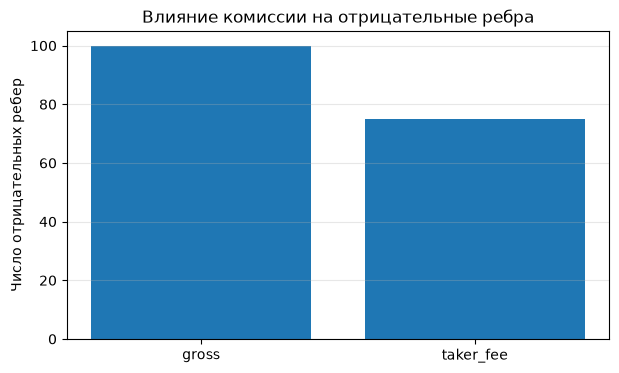

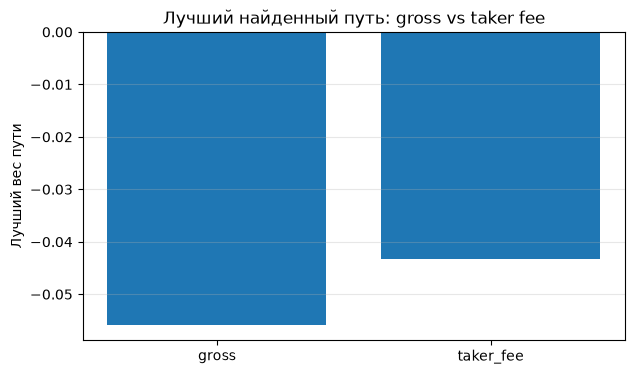

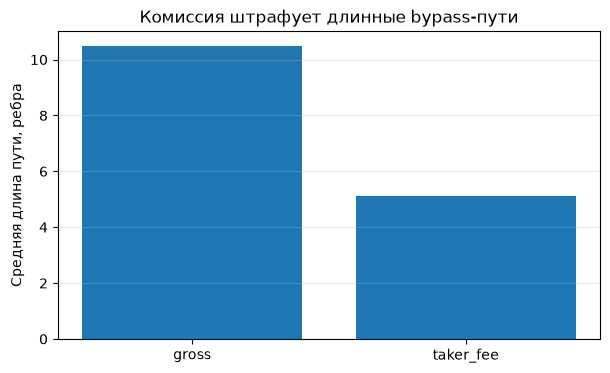

In [23]:
summary_path = OUT_DIR / "gpu_real_market_fee_compare_summary.csv"
if summary_path.exists():
    summary_plot_df = pd.read_csv(summary_path)

    plt.figure(figsize=(7, 4))
    plt.bar(summary_plot_df["model"], summary_plot_df["n_negative_edges"])
    plt.ylabel("Число отрицательных ребер")
    plt.title("Влияние комиссии на отрицательные ребра")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(summary_plot_df["model"], summary_plot_df["best_weight"])
    plt.ylabel("Лучший вес пути")
    plt.title("Лучший найденный путь: gross vs taker fee")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(summary_plot_df["model"], summary_plot_df["mean_path_length_edges"])
    plt.ylabel("Средняя длина пути, ребра")
    plt.title("Комиссия штрафует длинные bypass-пути")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## GPU-чувствительность к fee

In [25]:
RUN_FEE_GRID = True

FEE_GRID = [0.0, 0.0005, 0.001, 0.002, 0.005]
MAX_PAIRS_FEE_GRID = 10

def run_fee_sensitivity_gpu():
    rows = []

    for fee in FEE_GRID:
        print("\nfee =", fee)

        w_fee = build_market_weights_with_fee(
            ask=ask_norm,
            bid=bid_norm,
            sim=sim,
            fee_rate=fee,
            return_components=False,
        )

        diag = weight_diagnostics(w_fee, SYMBOLS_USED, f"fee_{fee:g}")

        pairs, stats_df = find_multiple_pairs_gpu(
            w=w_fee,
            threshold=THRESHOLD,
            max_pairs=MAX_PAIRS_FEE_GRID,
            sb_variant=SB_VARIANT,
            n_runs_per_pair=N_RUNS_PER_PAIR,
            n_iter=N_ITER,
            dt=DT,
            mc=MC,
            mp=MP,
            seed=SEED,
            debug=True,
            dtype_str=DTYPE_STR,
            use_sparse=USE_SPARSE,
            hard_tabu=HARD_TABU,
        )

        row = make_summary_row(f"fee_{fee:g}", pairs, stats_df, diag)
        row["fee_rate"] = fee
        rows.append(row)

    fee_sens_df = pd.DataFrame(rows)
    fee_sens_df.to_csv(OUT_DIR / "gpu_real_market_fee_sensitivity_summary.csv", index=False)
    return fee_sens_df

if RUN_FEE_GRID:
    fee_sens_df = run_fee_sensitivity_gpu()
    display(fee_sens_df)
else:
    print("Fee grid is disabled. Set RUN_FEE_GRID=True to run.")


fee = 0.0
[k=0] best weight=-0.05507437, path=[2, 8, 3, 14, 9, 11, 15, 4, 12, 6, 1, 5, 7, 10], valid_rate=0.380, core=592.952 ms, total=631.700 ms
[k=1] best weight=-0.05591455, path=[12, 6, 1, 3, 5, 11, 10, 4, 2, 13, 14, 9, 15], valid_rate=0.420, core=486.979 ms, total=515.471 ms
[k=2] best weight=-0.05198566, path=[2, 7, 14, 6, 10, 4, 12, 13], valid_rate=0.490, core=463.970 ms, total=489.524 ms
[k=3] best weight=-0.05171595, path=[12, 6, 11, 15, 1, 8, 10, 4, 2, 13], valid_rate=0.480, core=424.162 ms, total=449.055 ms
[k=4] best weight=-0.05410303, path=[12, 15, 4, 2, 13, 14, 6, 1, 10], valid_rate=0.450, core=434.971 ms, total=460.824 ms
[k=5] best weight=-0.05551743, path=[2, 10, 14, 9, 13, 4, 12, 6, 1, 7, 11, 15], valid_rate=0.390, core=411.117 ms, total=436.140 ms
[k=6] best weight=-0.05283919, path=[2, 13, 14, 15, 1, 8, 11, 10, 4, 12, 6], valid_rate=0.330, core=410.833 ms, total=438.107 ms
[k=7] best weight=-0.05292531, path=[2, 13, 14, 6, 1, 9, 10, 4, 12, 5, 11, 7, 15, 3], valid

,model,n_pairs,n_unique_endpoint_pairs,best_weight,mean_weight,mean_path_length_edges,n_negative_edges,share_negative_edges,mean_valid_rate,sum_gpu_core_ms,sum_total_ms,fee_rate
0,fee_0,10,10,-0.055915,-0.052573,10.5,100,0.476190,0.393,4471.476807,4742.1458,0.0000
1,fee_0.0005,10,10,-0.048357,-0.044323,6.2,85,0.404762,0.406,4251.957367,4506.6979,0.0005
2,fee_0.001,10,10,-0.043223,-0.039789,5.1,75,0.357143,0.375,4234.833984,4489.3679,0.0010
3,fee_0.002,10,10,-0.035685,-0.030742,4.5,54,0.257143,0.316,4432.111389,4678.8547,0.0020
4,fee_0.005,10,10,-0.016694,-0.012590,1.0,26,0.123810,0.143,4246.383484,4486.7977,0.0050
